In [1]:
import numpy as np
import pandas as pd
import scanpy as sc 

adata = sc.read_h5ad("dataset_co_mo.h5ad")

In [2]:
# Data prep
sc.pp.normalize_total(adata, target_sum=1e4) # You can adjust target_sum # Seems not to help
sc.pp.log1p(adata)

In [3]:
# Extract source and receiver genes efficiently
gl_source = ['TGFBR2', 'SMAD3', 'HIF1A', 'PDGFB'] # All values from the first column
#gl_recv =['PDGFRB', 'FN1', 'TGFB1']  # All values from the second column
gl_recv =['PDGFRB', 'TGFB1']  # All values from the second column
np.random.seed(42) 

In [4]:
ict1 = adata.obs["BatchID"] == "Cancer Cells (Co)"
ict2 = adata.obs["BatchID"] == "Fibroblasts (Co)" 

adata_ct1_co = adata[ict1, gl_source]
adata_ct2_co = adata[ict2, gl_recv]
adata_ct1_co = sc.external.pp.magic(adata_ct1_co, name_list=gl_source, knn=5, random_state=42)
adata_ct2_co = sc.external.pp.magic(adata_ct2_co, name_list=gl_recv, knn=5, random_state=42)

print(adata_ct1_co)
print(adata_ct2_co)

#Xct1_co = adata_ct1_co.X.toarray()
#Xct2_co = adata_ct2_co.X.toarray()
Xct1_co = adata_ct1_co.X
Xct2_co = adata_ct2_co.X

# Assuming Xct1_co and Xct2 are your log-transformed expression matrices
Xct1means = np.mean(Xct1_co, axis=0)
Xct2means = np.mean(Xct2_co, axis=0)
print("CT1 (Co) mean expression:", Xct1means)
print("CT2 (Co) mean expression:", Xct2means)

# Binarize Xct1
Xct1_binary_co = (Xct1_co > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_co = (Xct2_co > Xct2means).astype(int)

# Calculate the proportion of cells with expression above mean for each gene in ct1
Xct1p_co = np.sum(Xct1_binary_co, axis=0) / len(Xct1_binary_co[:, 0])
# Calculate the proportion of cells with expression above mean for each gene in ct2
Xct2p_co = np.sum(Xct2_binary_co, axis=0) / len(Xct2_binary_co[:, 0])

print("CT1 (Co) Percentages:", Xct1p_co)
print("CT2 (Co) Percentages:", Xct2p_co)

# Scale the data from 0 to 1 to -pi/2 to pi/2 | 2*pi or pi?
ct1_percentages_co = Xct1p_co * np.pi*2
ct2_percentages_co = Xct2p_co * np.pi*2
# Display the resulting scaled data
print("Scaled (Co) ct1_data:\n", ct1_percentages_co)
print("Scaled (Co) ct2_data:\n", ct2_percentages_co)

AnnData object with n_obs × n_vars = 1414 × 4
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
AnnData object with n_obs × n_vars = 1324 × 2
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
CT1 (Co) mean expression: [0.29251519 1.08644702 1.43469845 0.27864267]
CT2 (Co) mean expression: [0.57572907 0.71984594]
CT1 (Co) Percentages: [0.37340877 0.56152758 0.55799151 0.29773692]
CT2 (Co) Percentages: [0.41993958 0.51359517]
Scaled (Co) ct1_data:
 [2.34619649 3.52818185 3.50596408 1.87073622]
Scaled (Co) ct2_data:
 [2.63855818 3.2270136 ]


c:\Local_install\miniconda3\envs\qiskit-env\Lib\site-packages\sklearn\neighbors\_base.py:598: UserWarning: cannot use tree with sparse input: using brute force
  warnings.warn("cannot use tree with sparse input: using brute force")
c:\Local_install\miniconda3\envs\qiskit-env\Lib\site-packages\graphtools\graphs.py:290: RuntimeWarning: Detected zero distance between 466 pairs of samples. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(
c:\Local_install\miniconda3\envs\qiskit-env\Lib\site-packages\graphtools\base.py:554: RuntimeWarning: K should have a non-zero diagonal
  warnings.warn("K should have a non-zero diagonal", RuntimeWarning)
c:\Local_install\miniconda3\envs\qiskit-env\Lib\site-packages\sklearn\neighbors\_base.py:598: UserWarning: cannot use tree with sparse input: using brute force
  warnings.warn("cannot use tree with sparse input: using brute force")
c:\Local_install\miniconda3\envs\qiskit-env\Lib\site-packages\graphtools\graphs.py:290

In [5]:
ict1 = adata.obs["BatchID"] == "Cancer Cells (Mo)"
ict2 = adata.obs["BatchID"] == "Fibroblasts (Mo)" 

adata_ct1_mo = adata[ict1, gl_source]
adata_ct2_mo = adata[ict2, gl_recv]
adata_ct1_mo = sc.external.pp.magic(adata_ct1_mo, name_list=gl_source, knn=5, random_state=42)
adata_ct2_mo = sc.external.pp.magic(adata_ct2_mo, name_list=gl_recv, knn=5, random_state=42)


print(adata_ct1_mo)
print(adata_ct2_mo)

# Library size normalization 
#Xct1_mo = adata_ct1_mo.X.toarray()
#Xct2_mo = adata_ct2_mo.X.toarray()
Xct1_mo = adata_ct1_mo.X
Xct2_mo = adata_ct2_mo.X


# Assuming Xct1_co and Xct2 are your log-transformed expression matrices
#Xct1means = np.mean(Xct1_mo, axis=0)
#Xct2means = np.mean(Xct2_mo, axis=0)
#print("CT1 (Co) mean expression:", Xct1means)
#print("CT2 (Co) mean expression:", Xct2means)

# Utilize the mono cultured means here
# Binarize Xct1
Xct1_binary_mo = (Xct1_mo > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_mo = (Xct2_mo > Xct2means).astype(int)

# Calculate the proportion of cells with expression above mean for each gene in ct1
Xct1p_mo = np.sum(Xct1_binary_mo, axis=0) / len(Xct1_binary_mo[:, 0])

# Calculate the proportion of cells with expression above mean for each gene in ct2
Xct2p_mo = np.sum(Xct2_binary_mo, axis=0) / len(Xct2_binary_mo[:, 0])

print("CT1 (Mo) Percentages:", Xct1p_mo)
print("CT2 (Mo) Percentages:", Xct2p_mo)

# Scale the data from 0 to 1 to -pi/2 to pi/2 | 2*pi or pi?
ct1_percentages_mo = Xct1p_mo * np.pi*2
ct2_percentages_mo = Xct2p_mo * np.pi*2
# Display the resulting scaled data
print("Scaled (Mo) ct1_data:\n", ct1_percentages_mo)
print("Scaled (Mo) ct2_data:\n", ct2_percentages_mo)

c:\Local_install\miniconda3\envs\qiskit-env\Lib\site-packages\sklearn\neighbors\_base.py:598: UserWarning: cannot use tree with sparse input: using brute force
  warnings.warn("cannot use tree with sparse input: using brute force")
c:\Local_install\miniconda3\envs\qiskit-env\Lib\site-packages\graphtools\graphs.py:290: RuntimeWarning: Detected zero distance between 743 pairs of samples. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(
c:\Local_install\miniconda3\envs\qiskit-env\Lib\site-packages\graphtools\base.py:554: RuntimeWarning: K should have a non-zero diagonal
  warnings.warn("K should have a non-zero diagonal", RuntimeWarning)
c:\Local_install\miniconda3\envs\qiskit-env\Lib\site-packages\sklearn\neighbors\_base.py:598: UserWarning: cannot use tree with sparse input: using brute force
  warnings.warn("cannot use tree with sparse input: using brute force")
c:\Local_install\miniconda3\envs\qiskit-env\Lib\site-packages\graphtools\graphs.py:290

AnnData object with n_obs × n_vars = 2364 × 4
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
AnnData object with n_obs × n_vars = 2788 × 2
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
CT1 (Mo) Percentages: [0.36675127 0.55837563 0.58629442 0.09390863]
CT2 (Mo) Percentages: [0.29196557 0.42109039]
Scaled (Mo) ct1_data:
 [2.30436618 3.50837758 3.68379646 0.59004532]
Scaled (Mo) ct2_data:
 [1.83447376 2.64578893]


c:\Local_install\miniconda3\envs\qiskit-env\Lib\site-packages\graphtools\base.py:554: RuntimeWarning: K should have a non-zero diagonal
  warnings.warn("K should have a non-zero diagonal", RuntimeWarning)


In [6]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from histogram_functions import create_joint_histogram, plot_joint_histogram

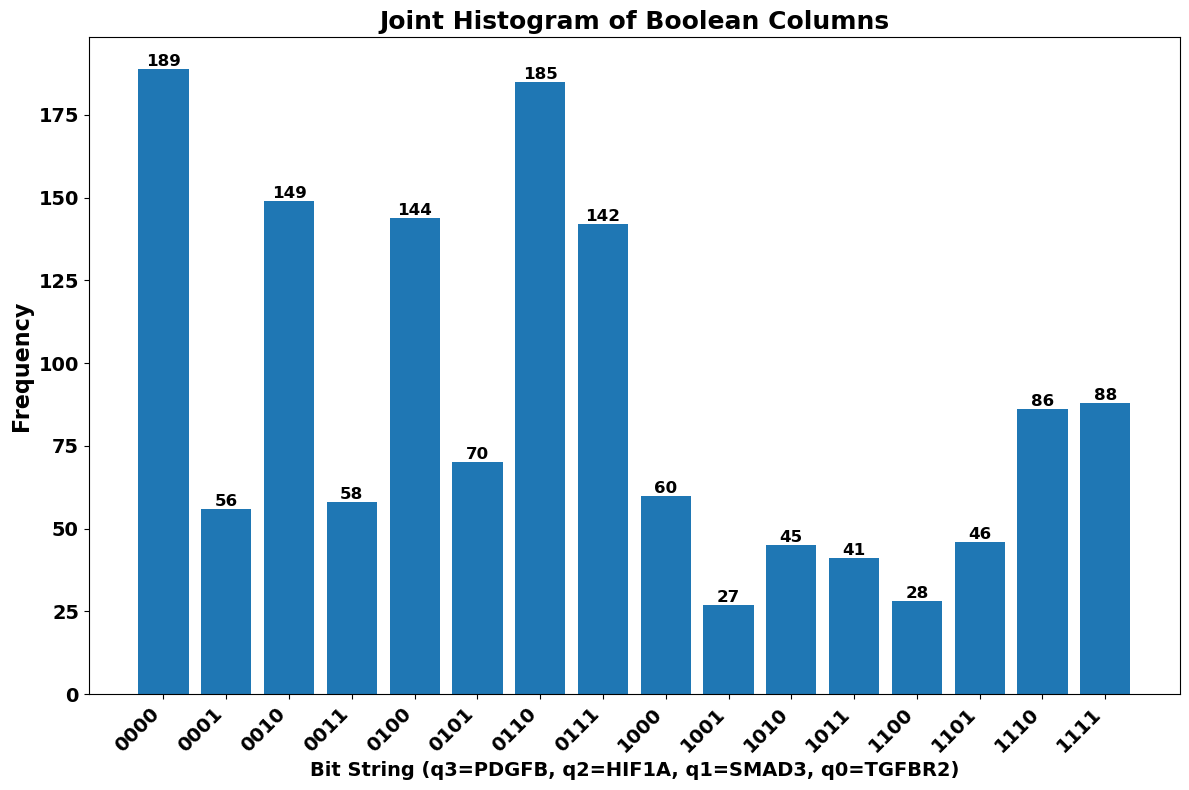

Joint Counts: Counter({'0000': 189, '0110': 185, '0100': 149, '0010': 144, '1110': 142, '1111': 88, '0111': 86, '1010': 70, '0001': 60, '1100': 58, '1000': 56, '1011': 46, '0101': 45, '1101': 41, '0011': 28, '1001': 27})
Bit Strings: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [7]:
joint_counts_ct1_co, bit_strings_ct1_co = create_joint_histogram(Xct1_binary_co)

num_qubits = Xct1_binary_co.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct1_co, num_qubits, reverse_bits=True, features=gl_source)  # Pass num_qubits

print("Joint Counts:", joint_counts_ct1_co)
print("Bit Strings:", bit_strings_ct1_co)

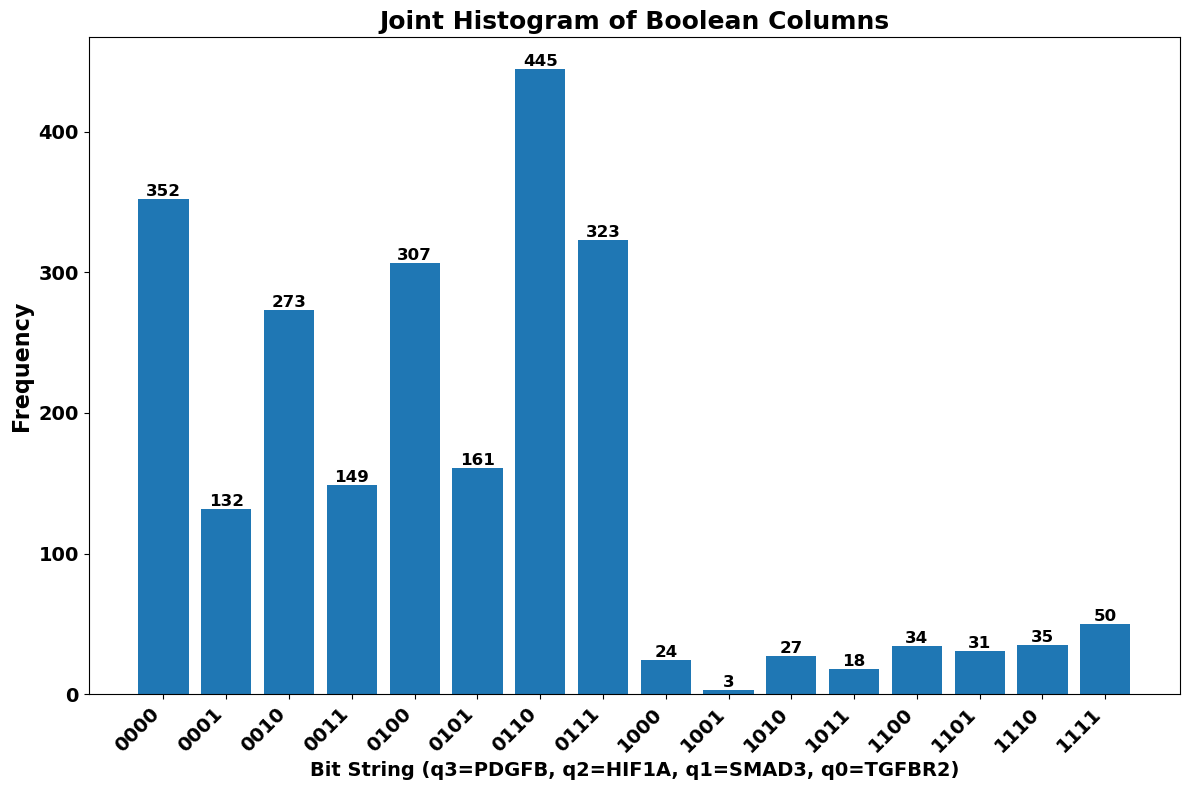

Joint Counts: Counter({'0110': 445, '0000': 352, '1110': 323, '0010': 307, '0100': 273, '1010': 161, '1100': 149, '1000': 132, '1111': 50, '0111': 35, '0011': 34, '1011': 31, '0101': 27, '0001': 24, '1101': 18, '1001': 3})
Bit Strings: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [8]:
joint_counts_ct1_mo, bit_strings_ct1_mo = create_joint_histogram(Xct1_binary_mo)

num_qubits = Xct1_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct1_mo, num_qubits, reverse_bits=True, features=gl_source )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct1_mo)
print("Bit Strings:", bit_strings_ct1_mo)

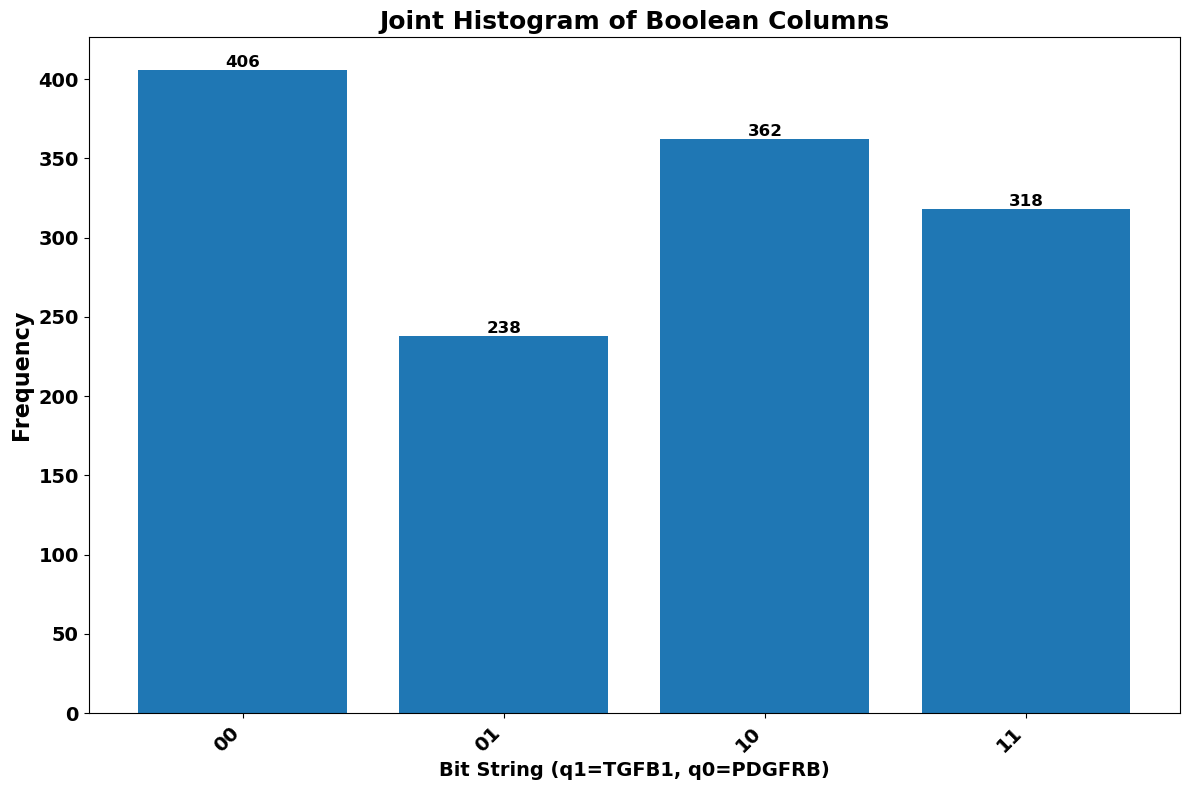

Joint Counts: Counter({'00': 406, '01': 362, '11': 318, '10': 238})
Bit Strings: ['00', '01', '10', '11']


In [9]:
joint_counts_ct2_co, bit_strings_ct2_co = create_joint_histogram(Xct2_binary_co)

num_qubits2 = Xct2_binary_co.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_co, num_qubits2, reverse_bits=True, features=gl_recv)  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_co)
print("Bit Strings:", bit_strings_ct2_co)

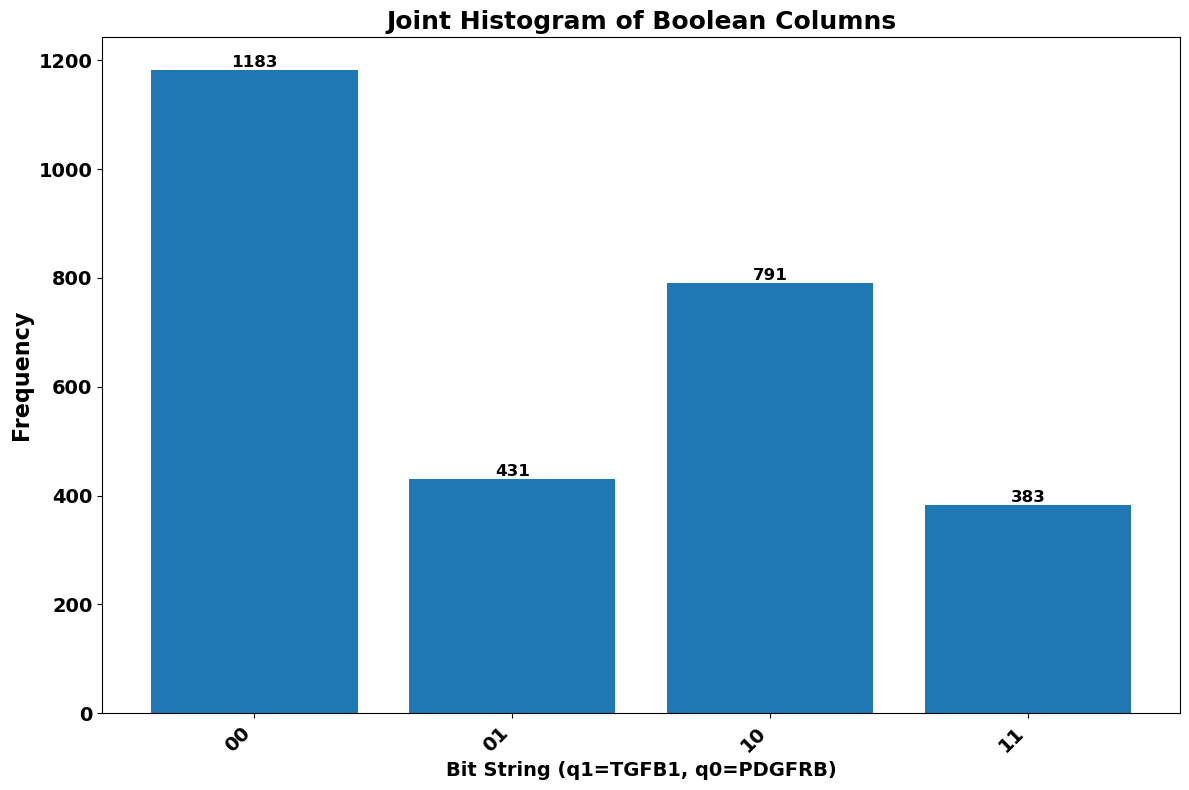

Joint Counts: Counter({'00': 1183, '01': 791, '10': 431, '11': 383})
Bit Strings: ['00', '01', '10', '11']


In [10]:
joint_counts_ct2_mo, bit_strings_ct2_mo = create_joint_histogram(Xct2_binary_mo)

num_qubits2 = Xct2_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_mo, num_qubits2, reverse_bits=True, features=gl_recv)  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_mo)
print("Bit Strings:", bit_strings_ct2_mo)

In [11]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from quantum_functions import create_grn_ansatz, create_interaction_observable_from_histogram, evaluate_and_plot_ansatz
from quantum_functions import create_parameter_dictionaries, cost_func_vqe, cost_func_wrapper
from quantum_functions import create_interaction_observable_general, create_parameter_dictionaries_from_circuit, create_circuit_lr2


findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


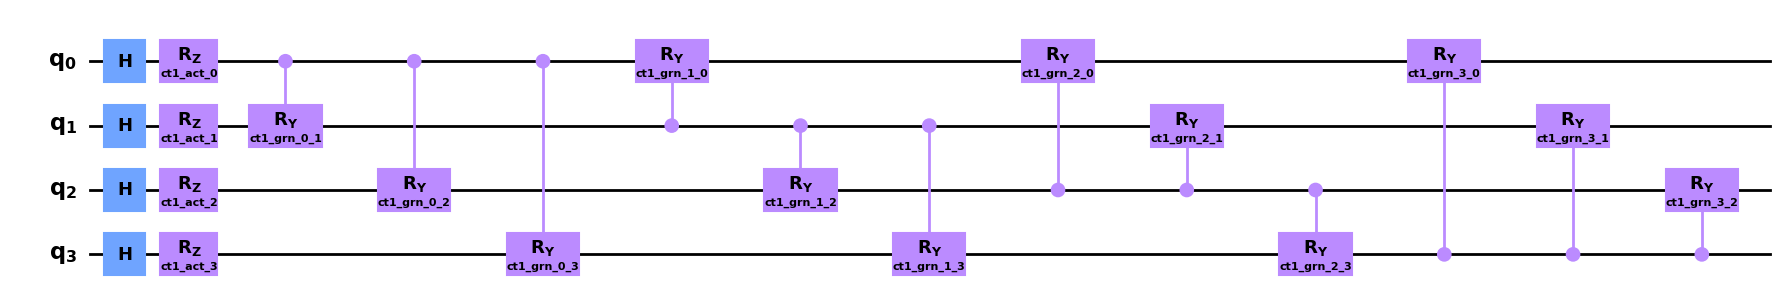

In [12]:
ng_ct1 = len(gl_source)  # Assuming gl_source is defined elsewhere
# Create mono coltured grn
ansatz_grn_ct1_mo = create_grn_ansatz(ng_ct1, "CT1")
# Create co cultured grn
ansatz_grn_ct1_co = create_grn_ansatz(ng_ct1, "CT1")
ansatz_grn_ct1_mo.draw(output="mpl", style="clifford", fold=40)

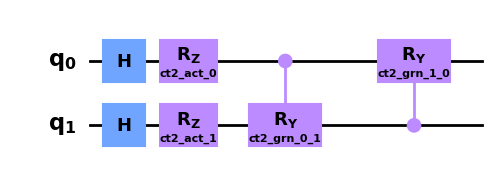

In [13]:
ng_ct2 = len(gl_recv)  #Example for a second cell type
# Create mo cultured grn
ansatz_grn_ct2_mo = create_grn_ansatz(ng_ct2, "CT2")
# Create co cultured grn
ansatz_grn_ct2_co = create_grn_ansatz(ng_ct2, "CT2")
ansatz_grn_ct2_mo.draw(output="mpl", style="clifford", fold=40)

Interaction observable CT1 from histogram: SparsePauliOp(['IZZZ', 'ZIZI', 'IIZZ', 'IZZI', 'IZII', 'IIZI', 'ZZII', 'ZZZI', 'ZIIZ', 'ZZIZ', 'ZIZZ', 'ZZZZ', 'IIIZ', 'ZIII', 'IZIZ'],
              coeffs=[ 86.+0.j,  70.+0.j,  28.+0.j, 185.+0.j, 149.+0.j, 144.+0.j,  58.+0.j,
 142.+0.j,  27.+0.j,  41.+0.j,  46.+0.j,  88.+0.j,  60.+0.j,  56.+0.j,
  45.+0.j])
Static Parameters: {Parameter(ct1_act_0): 2.3461964937700293, Parameter(ct1_act_1): 3.528181848585991, Parameter(ct1_act_2): 3.5059640787586233, Parameter(ct1_act_3): 1.8707362194643606}
Variable Parameters: [Parameter(ct1_grn_0_1), Parameter(ct1_grn_0_2), Parameter(ct1_grn_0_3), Parameter(ct1_grn_1_0), Parameter(ct1_grn_1_2), Parameter(ct1_grn_1_3), Parameter(ct1_grn_2_0), Parameter(ct1_grn_2_1), Parameter(ct1_grn_2_3), Parameter(ct1_grn_3_0), Parameter(ct1_grn_3_1), Parameter(ct1_grn_3_2)]
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -178.47273943578335
        x: [-1.571e+00  6

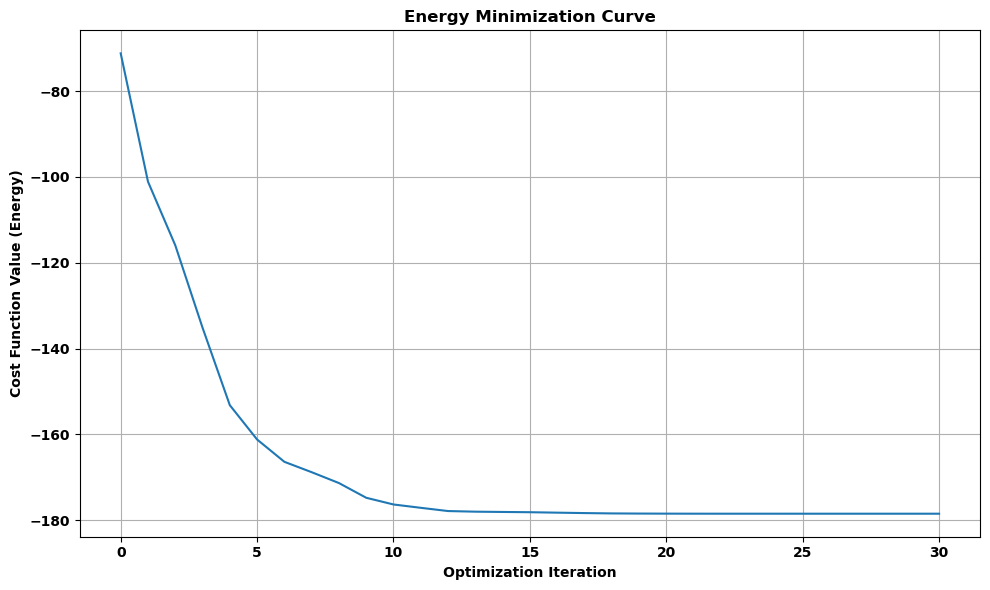

In [14]:
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

min_ones_ct1 = 1 # 1 is good 2 produces clean cuts
num_features = Xct1_binary_co.shape[1]  # Get the number of features dynamically

interaction_observable_ct1_co = create_interaction_observable_from_histogram(joint_counts_ct1_co, num_features, min_ones = min_ones_ct1)
print("Interaction observable CT1 from histogram:", interaction_observable_ct1_co)

static_params, variable_params = create_parameter_dictionaries(ansatz_grn_ct1_co, ct1_percentages_co)

print("Static Parameters:", static_params)
print("Variable Parameters:", variable_params)

estimator = StatevectorEstimator()

# Initialize variable parameters
x0_interaction = np.zeros(len(variable_params))  # All zeros

# Create initial full parameter dictionary - THIS IS THE KEY CHANGE
all_params_ct1_co = static_params.copy()  # Start with static parameters
all_params_ct1_co.update(dict(zip(variable_params, x0_interaction)))  # Add variable parameters

cost_values = []
# Call minimize with args
result_interaction_bfgs = minimize(
    cost_func_wrapper,
    x0_interaction,
    args=(all_params_ct1_co, ansatz_grn_ct1_co, interaction_observable_ct1_co, estimator, variable_params), # Pass all the arguments as a tuple
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params_ct1_co, ansatz_grn_ct1_co, interaction_observable_ct1_co, estimator, variable_params))
)

print(result_interaction_bfgs)

# --- 6. Results and DataFrame ---
optimized_variable_parameters = result_interaction_bfgs.x

# Update the full parameter dictionary with optimized variable parameters
for param, value in zip(variable_params, optimized_variable_parameters):
    all_params_ct1_co[param] = value

import matplotlib.pyplot as plt

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

Interaction observable CT1 from histogram: SparsePauliOp(['IZZI', 'IIZI', 'ZZZZ', 'ZZII', 'IZII', 'ZZZI', 'IZZZ', 'ZIII', 'ZZIZ', 'ZIZI', 'ZIZZ', 'IZIZ', 'IIZZ', 'IIIZ', 'ZIIZ'],
              coeffs=[445.+0.j, 307.+0.j,  50.+0.j, 149.+0.j, 273.+0.j, 323.+0.j,  35.+0.j,
 132.+0.j,  18.+0.j, 161.+0.j,  31.+0.j,  27.+0.j,  34.+0.j,  24.+0.j,
   3.+0.j])
Static Parameters: {Parameter(ct1_act_0): 2.3043661849935284, Parameter(ct1_act_1): 3.5083775826891093, Parameter(ct1_act_2): 3.683796461823565, Parameter(ct1_act_3): 0.5900453207249865}
Variable Parameters: [Parameter(ct1_grn_0_1), Parameter(ct1_grn_0_2), Parameter(ct1_grn_0_3), Parameter(ct1_grn_1_0), Parameter(ct1_grn_1_2), Parameter(ct1_grn_1_3), Parameter(ct1_grn_2_0), Parameter(ct1_grn_2_1), Parameter(ct1_grn_2_3), Parameter(ct1_grn_3_0), Parameter(ct1_grn_3_1), Parameter(ct1_grn_3_2)]
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -445.40624599661083
        x: [-1.502e+00 -9

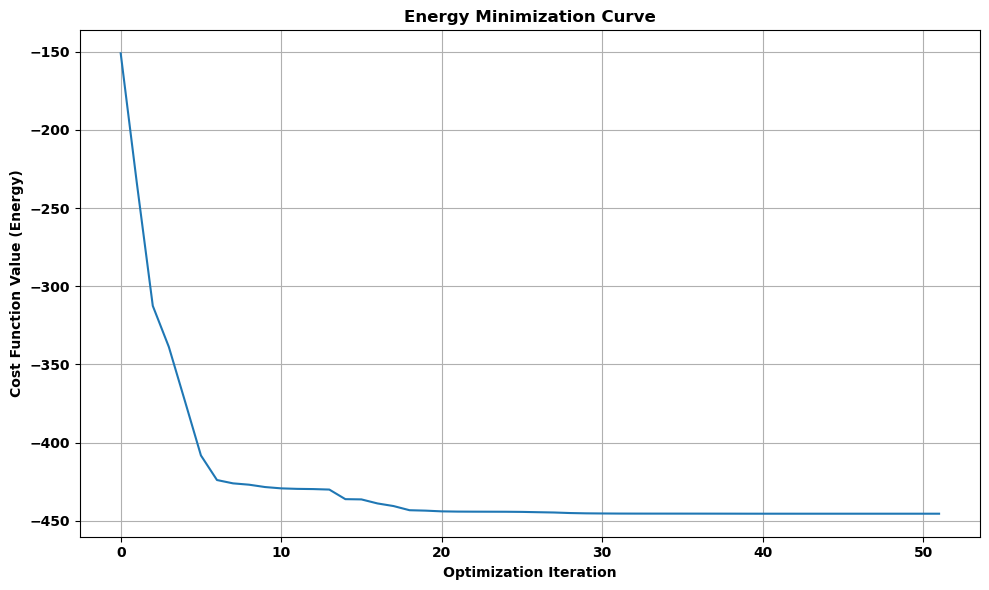

In [15]:
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

num_features = Xct1_binary_mo.shape[1]  # Get the number of features dynamically

interaction_observable_ct1_mo = create_interaction_observable_from_histogram(joint_counts_ct1_mo, num_features, min_ones = min_ones_ct1)
print("Interaction observable CT1 from histogram:", interaction_observable_ct1_mo)

static_params, variable_params = create_parameter_dictionaries(ansatz_grn_ct1_mo, ct1_percentages_mo)

print("Static Parameters:", static_params)
print("Variable Parameters:", variable_params)

estimator = StatevectorEstimator()

# Initialize variable parameters
x0_interaction = np.zeros(len(variable_params))  # All zeros

# Create initial full parameter dictionary - THIS IS THE KEY CHANGE
all_params_ct1_mo = static_params.copy()  # Start with static parameters
all_params_ct1_mo.update(dict(zip(variable_params, x0_interaction)))  # Add variable parameters

cost_values = []
# Call minimize with args
result_interaction_bfgs = minimize(
    cost_func_wrapper,
    x0_interaction,
    args=(all_params_ct1_mo, ansatz_grn_ct1_mo, interaction_observable_ct1_mo, estimator, variable_params), # Pass all the arguments as a tuple
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params_ct1_mo, ansatz_grn_ct1_mo, interaction_observable_ct1_mo, estimator, variable_params))
)

print(result_interaction_bfgs)

# --- 6. Results and DataFrame ---
optimized_variable_parameters = result_interaction_bfgs.x

# Update the full parameter dictionary with optimized variable parameters
for param, value in zip(variable_params, optimized_variable_parameters):
    all_params_ct1_mo[param] = value

import matplotlib.pyplot as plt

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

The counts are: {'0010': 426, '1101': 55, '1011': 15, '1001': 31, '1111': 279, '0100': 101, '0000': 72, '0001': 7, '0011': 18, '1100': 11, '0101': 2, '0110': 2, '1000': 4, '1110': 1}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:135: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


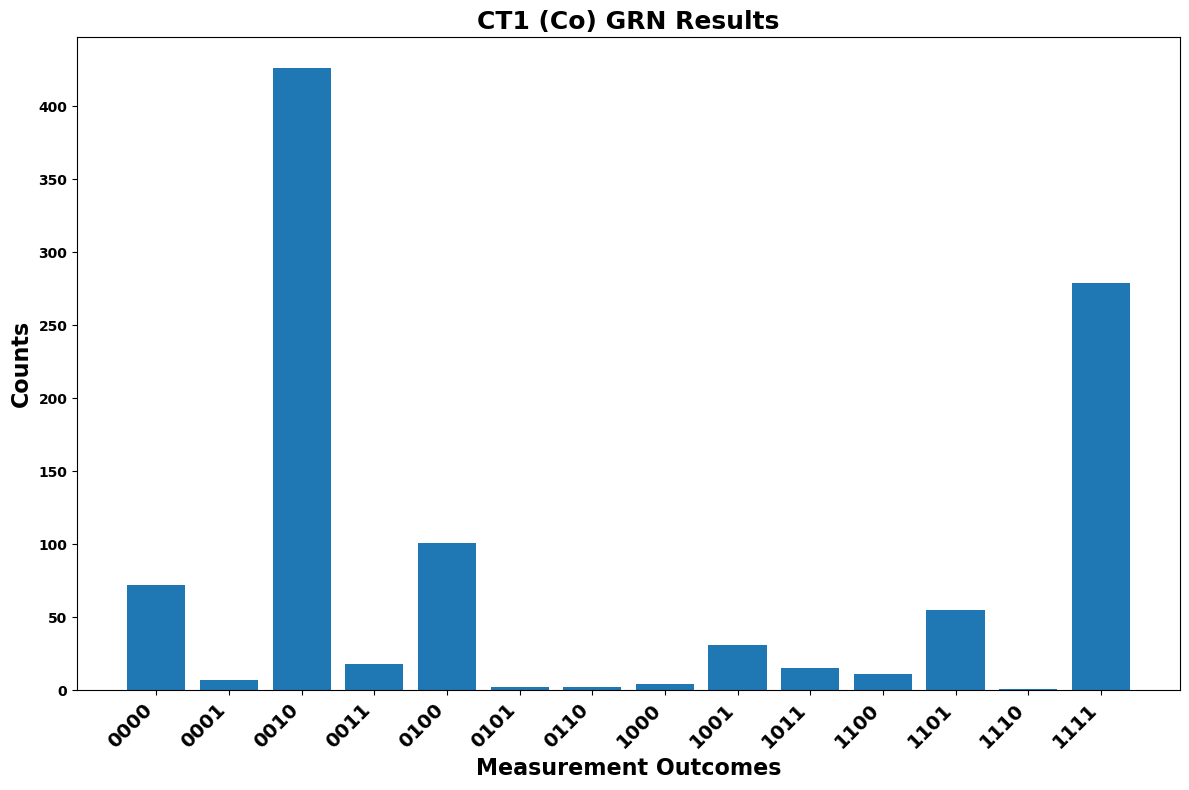

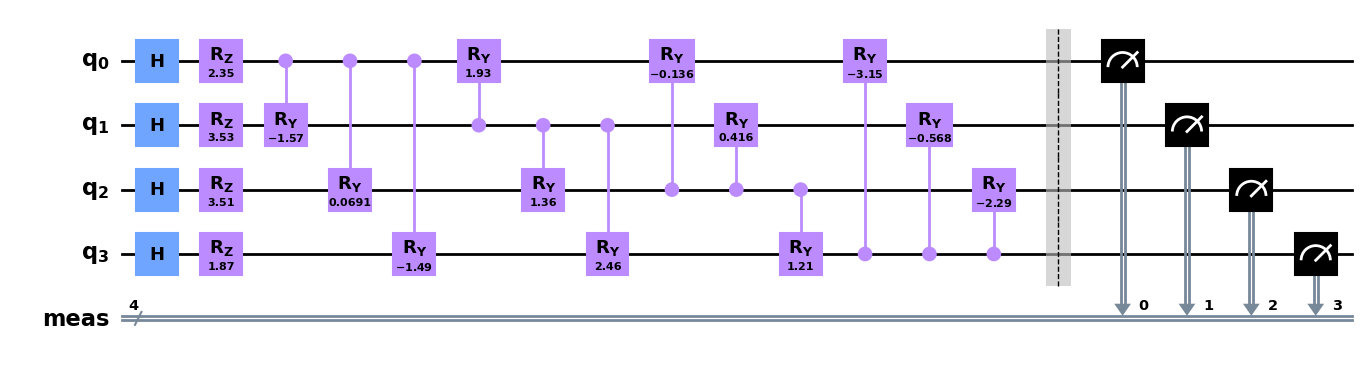

In [16]:
#counts_ct1_co, bound_circuit_ct1_co = evaluate_and_plot_ansatz(ansatz_grn_ct1_co, all_params_ct1_co, shots=sum(joint_counts_ct1_co.values()), title="CT1 (Co) GRN Results")
counts_ct1_co, bound_circuit_ct1_co = evaluate_and_plot_ansatz(ansatz_grn_ct1_co, all_params_ct1_co, shots=1024, title="CT1 (Co) GRN Results")

bound_circuit_ct1_co.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

The counts are: {'0100': 143, '0011': 144, '1101': 47, '0010': 464, '0111': 4, '0101': 18, '1111': 70, '1011': 35, '0000': 72, '1110': 10, '0110': 7, '1100': 7, '0001': 3}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:135: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


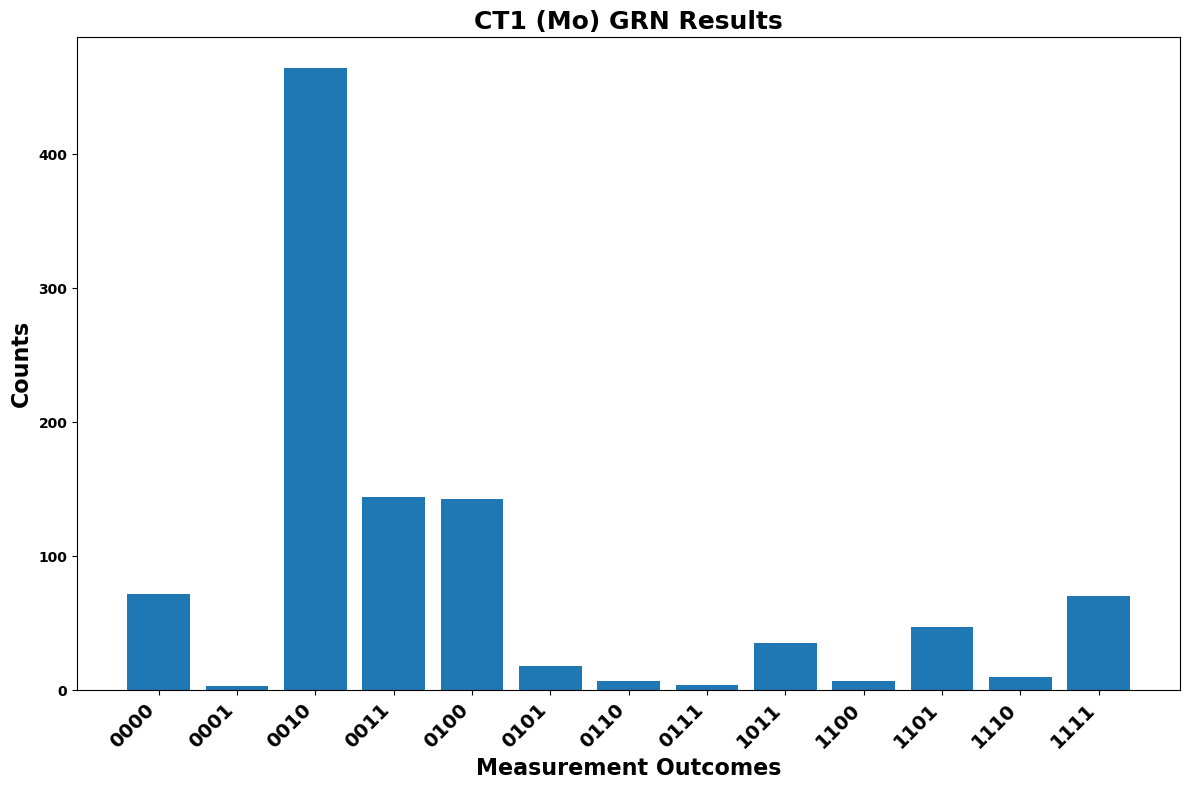

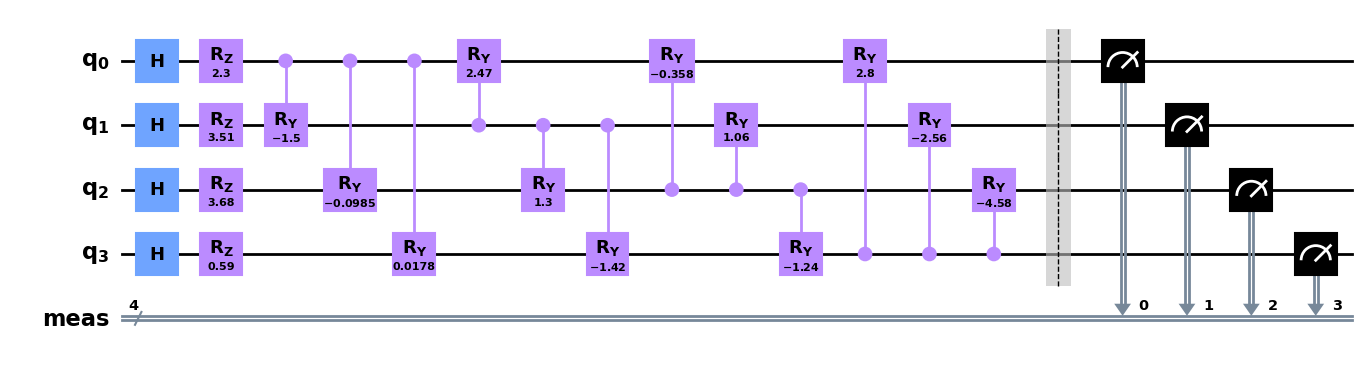

In [17]:
# Generating monocultured hitogram from ciruit
#counts_ct1_mo, bound_circuit_ct1_mo = evaluate_and_plot_ansatz(ansatz_grn_ct1_mo, all_params_ct1_mo, shots=sum(joint_counts_ct1_mo.values()), title="CT1 (Mo) GRN Results")
counts_ct1_mo, bound_circuit_ct1_mo = evaluate_and_plot_ansatz(ansatz_grn_ct1_mo, all_params_ct1_mo, shots=1024, title="CT1 (Mo) GRN Results")
bound_circuit_ct1_mo.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

Interaction observable CT2 from histogram: SparsePauliOp(['ZZ', 'IZ', 'ZI'],
              coeffs=[318.+0.j, 362.+0.j, 238.+0.j])
Static Parameters: {Parameter(ct2_act_0): 2.638558180356382, Parameter(ct2_act_1): 3.227013601874712}
Variable Parameters: [Parameter(ct2_grn_0_1), Parameter(ct2_grn_1_0)]
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -61.803209188917336
        x: [ 1.553e+00 -3.057e+00]
      nit: 10
      jac: [ 9.237e-06 -3.553e-06]
     nfev: 33
     njev: 11
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>


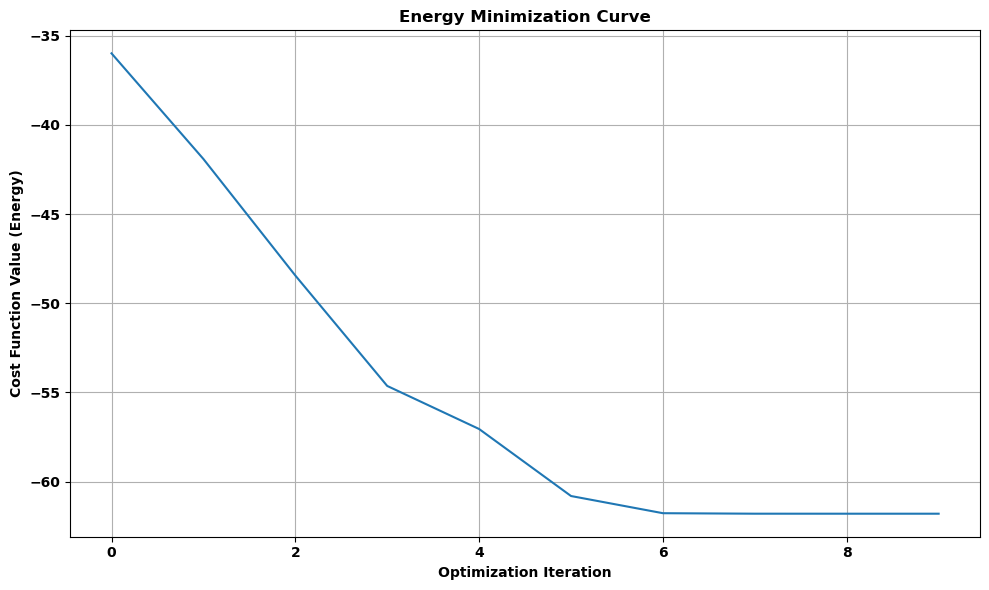

In [18]:
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

min_ones_ct2 = 1 # 1 is fine... 2 produces cleaner cuts
num_features2 = Xct2_binary_co.shape[1]  # Get the number of features dynamically

interaction_observable_ct2_co = create_interaction_observable_from_histogram(joint_counts_ct2_co, num_features2, min_ones = min_ones_ct2)
print("Interaction observable CT2 from histogram:", interaction_observable_ct2_co)

static_params2, variable_params2 = create_parameter_dictionaries(ansatz_grn_ct2_co, ct2_percentages_co)

print("Static Parameters:", static_params2)
print("Variable Parameters:", variable_params2)

estimator = StatevectorEstimator()
# Initialize variable parameters
x0_interaction = np.zeros(len(variable_params2))  # All zeros

# Create initial full parameter dictionary - THIS IS THE KEY CHANGE
all_params_ct2_co = static_params2.copy()  # Start with static parameters
all_params_ct2_co.update(dict(zip(variable_params2, x0_interaction)))  # Add variable parameters

cost_values = []
# Call minimize with args, using a lambda for the callback
result_interaction_bfgs = minimize(
    cost_func_wrapper,
    x0_interaction,
    args=(all_params_ct2_co, ansatz_grn_ct2_co, interaction_observable_ct2_co, estimator, variable_params2),
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params_ct2_co, ansatz_grn_ct2_co, interaction_observable_ct2_co, estimator, variable_params2))
)

print(result_interaction_bfgs)

# --- 6. Results and DataFrame ---
optimized_variable_parameters = result_interaction_bfgs.x

# Update the full parameter dictionary with optimized variable parameters
for param, value in zip(variable_params2, optimized_variable_parameters):
    all_params_ct2_co[param] = value

import matplotlib.pyplot as plt

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

Interaction observable CT2 from histogram: SparsePauliOp(['ZZ', 'IZ', 'ZI'],
              coeffs=[383.+0.j, 791.+0.j, 431.+0.j])
Static Parameters: {Parameter(ct2_act_0): 1.8344737589828493, Parameter(ct2_act_1): 2.64578893494578}
Variable Parameters: [Parameter(ct2_grn_0_1), Parameter(ct2_grn_1_0)]
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -183.88720625690092
        x: [-4.375e+00 -2.361e+00]
      nit: 13
      jac: [-8.527e-06  1.137e-05]
     nfev: 57
     njev: 19
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>


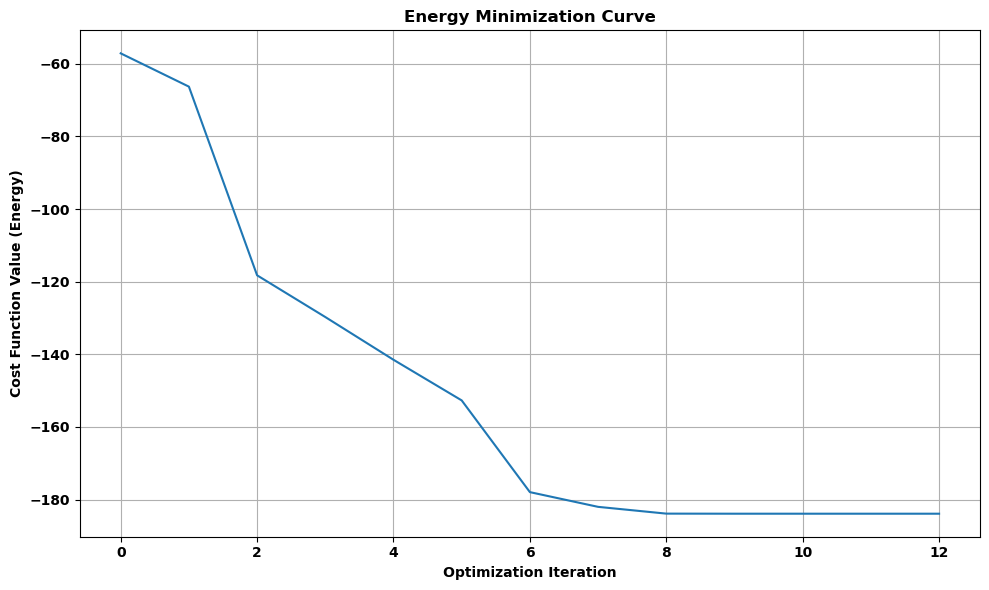

In [19]:
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

num_features2 = Xct2_binary_mo.shape[1]  # Get the number of features dynamically

interaction_observable_ct2_mo = create_interaction_observable_from_histogram(joint_counts_ct2_mo, num_features2, min_ones = min_ones_ct2)
print("Interaction observable CT2 from histogram:", interaction_observable_ct2_mo)

static_params2, variable_params2 = create_parameter_dictionaries(ansatz_grn_ct2_mo, ct2_percentages_mo)

print("Static Parameters:", static_params2)
print("Variable Parameters:", variable_params2)

estimator = StatevectorEstimator()
# Initialize variable parameters
x0_interaction = np.zeros(len(variable_params2))  # All zeros

# Create initial full parameter dictionary - THIS IS THE KEY CHANGE
all_params_ct2_mo = static_params2.copy()  # Start with static parameters
all_params_ct2_mo.update(dict(zip(variable_params2, x0_interaction)))  # Add variable parameters

cost_values = []
# Call minimize with args, using a lambda for the callback
result_interaction_bfgs = minimize(
    cost_func_wrapper,
    x0_interaction,
    args=(all_params_ct2_mo, ansatz_grn_ct2_mo, interaction_observable_ct2_mo, estimator, variable_params2),
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params_ct2_mo, ansatz_grn_ct2_mo, interaction_observable_ct2_mo, estimator, variable_params2))
)

print(result_interaction_bfgs)

# --- 6. Results and DataFrame ---
optimized_variable_parameters = result_interaction_bfgs.x

# Update the full parameter dictionary with optimized variable parameters
for param, value in zip(variable_params2, optimized_variable_parameters):
    all_params_ct2_mo[param] = value

import matplotlib.pyplot as plt

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

The counts are: {'01': 486, '11': 276, '00': 261, '10': 1}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:135: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


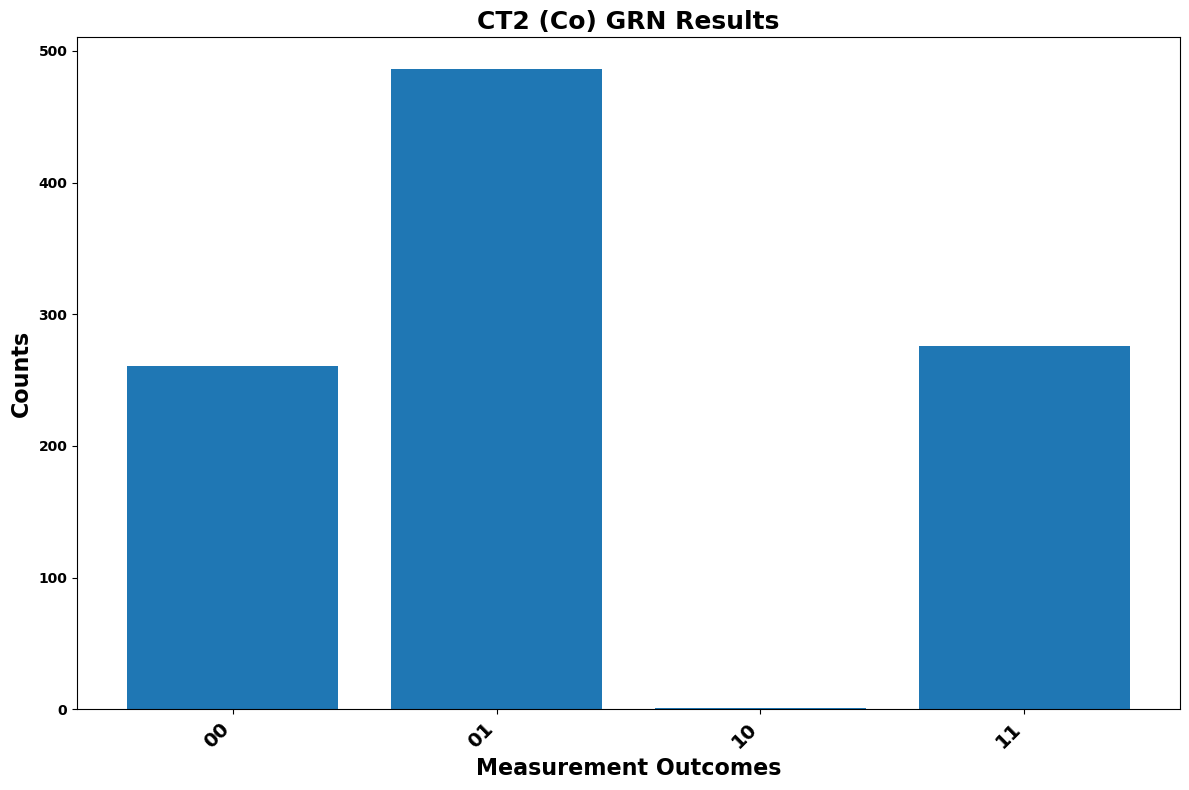

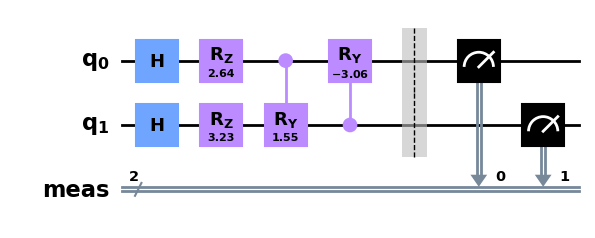

In [20]:
#counts_ct2_co, bound_circuit_ct2_co = evaluate_and_plot_ansatz(ansatz_grn_ct2_co, all_params_ct2_co,shots=sum(joint_counts_ct2_co.values()), title="CT2 (Co) GRN Results")
counts_ct2_co, bound_circuit_ct2_co = evaluate_and_plot_ansatz(ansatz_grn_ct2_co, all_params_ct2_co,shots=1024, title="CT2 (Co) GRN Results")
bound_circuit_ct2_co.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

The counts are: {'00': 257, '01': 450, '11': 317}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:135: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


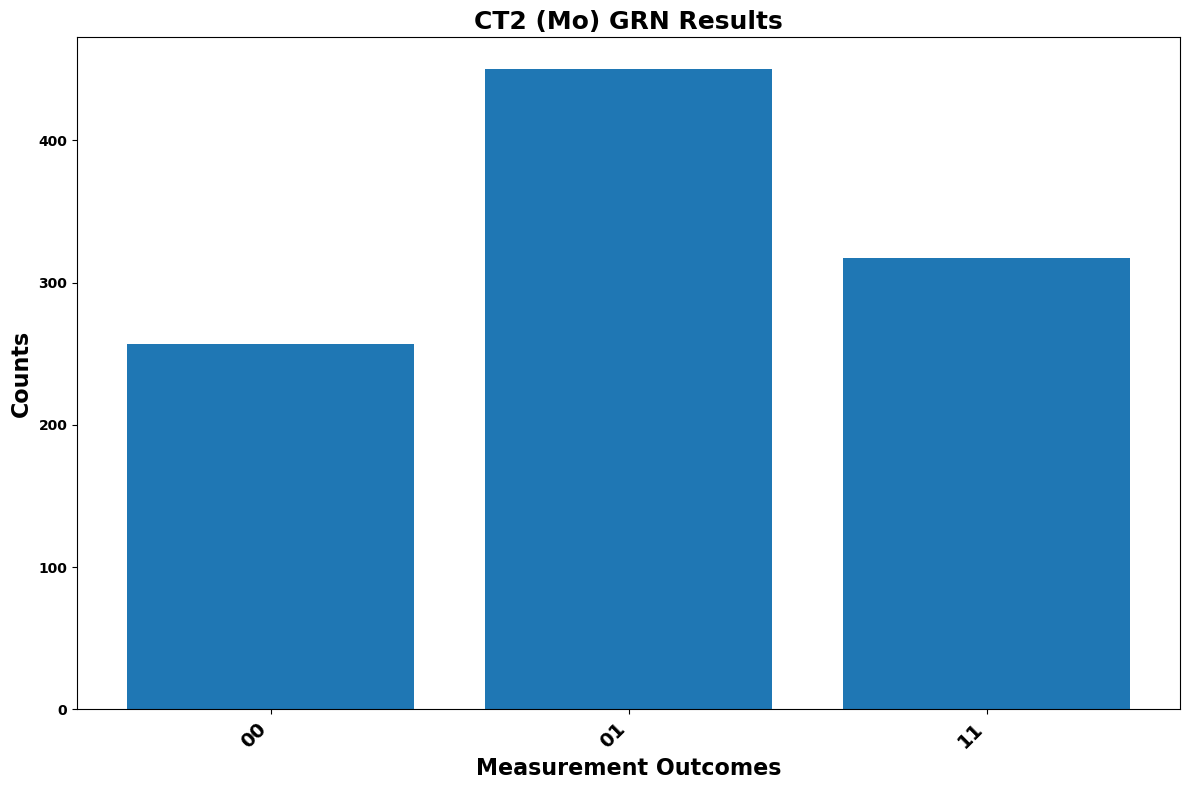

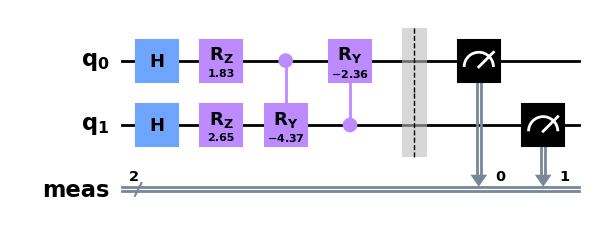

In [21]:
#counts_ct2_mo, bound_circuit_ct2_mo = evaluate_and_plot_ansatz(ansatz_grn_ct2_mo, all_params_ct2_mo, shots=sum(joint_counts_ct2_mo.values()), title="CT2 (Mo) GRN Results")
counts_ct2_mo, bound_circuit_ct2_mo = evaluate_and_plot_ansatz(ansatz_grn_ct2_mo, all_params_ct2_mo, shots=1024, title="CT2 (Mo) GRN Results")
bound_circuit_ct2_mo.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

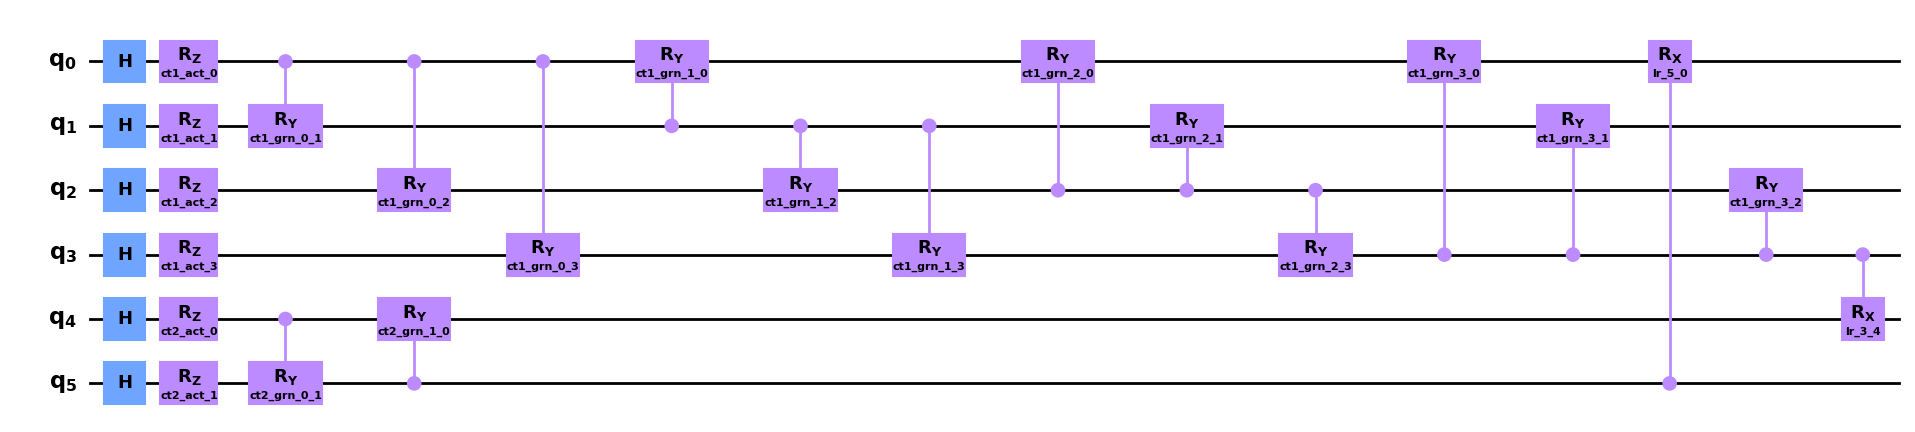

In [22]:
# interactions_lr = {
#     (4, 0): -1,
#     (3, 6): -1
# }
interactions_lr = {
    (ng_ct1 + ng_ct2 - 1, 0): 10,
    (ng_ct1-1, ng_ct1): 10
}

cc_grn_circuit_co = create_circuit_lr2(ansatz_grn_ct1_co, ansatz_grn_ct2_co, interactions = interactions_lr)
cc_grn_circuit_mo = create_circuit_lr2(ansatz_grn_ct1_mo, ansatz_grn_ct2_mo, interactions = interactions_lr)
cc_grn_circuit_mo.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

{Parameter(ct1_act_0): 2.3461964937700293, Parameter(ct1_act_1): 3.528181848585991, Parameter(ct1_act_2): 3.5059640787586233, Parameter(ct1_act_3): 1.8707362194643606, Parameter(ct1_grn_0_1): -1.570946821128821, Parameter(ct1_grn_0_2): 0.06905439552812402, Parameter(ct1_grn_0_3): -1.4852174861770533, Parameter(ct1_grn_1_0): 1.9287090801625404, Parameter(ct1_grn_1_2): 1.357376398739789, Parameter(ct1_grn_1_3): 2.460650829206204, Parameter(ct1_grn_2_0): -0.13567530314381884, Parameter(ct1_grn_2_1): 0.4157139489035506, Parameter(ct1_grn_2_3): 1.2135040797069876, Parameter(ct1_grn_3_0): -3.150633691096871, Parameter(ct1_grn_3_1): -0.5683960584797223, Parameter(ct1_grn_3_2): -2.292011022364254, Parameter(ct2_act_0): 2.638558180356382, Parameter(ct2_act_1): 3.227013601874712, Parameter(ct2_grn_0_1): 1.5525721447115528, Parameter(ct2_grn_1_0): -3.056782270966702, Parameter(lr_3_4): 0.0, Parameter(lr_5_0): 0.0}
Interaction observable LR custom:  SparsePauliOp(['ZIIIIZ', 'IIIZZI'],
            

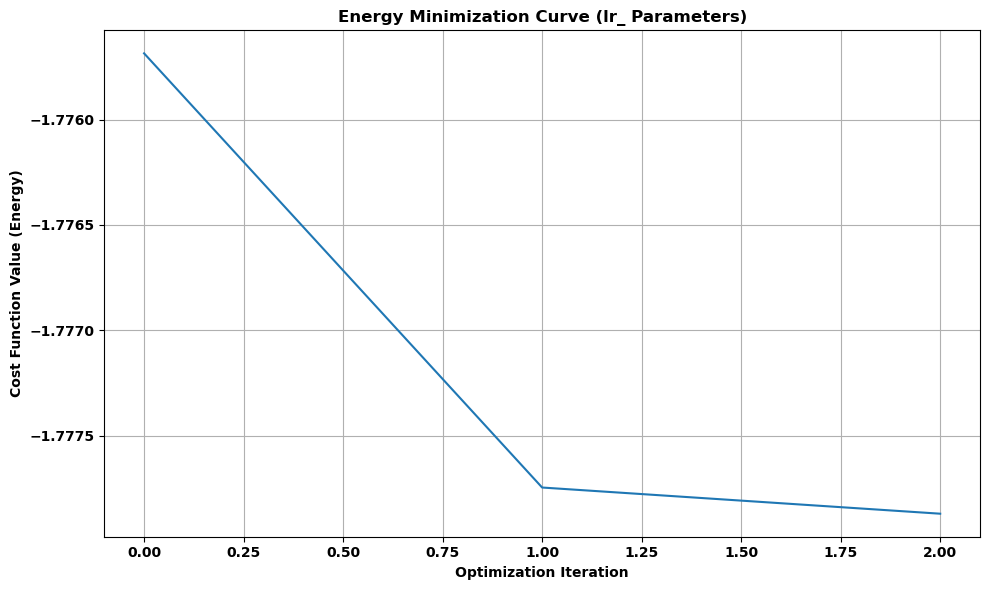

In [23]:
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector

estimator = StatevectorEstimator()

# --- 1. Create Static Parameter Dictionaries ---
static_params_lr, variable_params_lr = create_parameter_dictionaries_from_circuit(cc_grn_circuit_co)

# Update static_params_lr with values from all_params and all_params2
for param in static_params_lr:
    if param.name in [p.name for p in all_params_ct1_co]:
        # Access value directly by name
        static_params_lr[param] = all_params_ct1_co[next(p for p in all_params_ct1_co if p.name == param.name)]
    elif param.name in [p.name for p in all_params_ct2_co]:
        # Access value directly by name
        static_params_lr[param] = all_params_ct2_co[next(p for p in all_params_ct2_co if p.name == param.name)]
        
x0_lr = np.zeros(len(variable_params_lr))  # Initial lr_ values

# Create the combined parameter dictionary.
all_params_lr_co = static_params_lr.copy()
all_params_lr_co.update(dict(zip(variable_params_lr, x0_lr)))

print(all_params_lr_co)

interaction_observable_lr_co = create_interaction_observable_general(interactions_lr, ng_ct1 + ng_ct2)
print("Interaction observable LR custom: ", interaction_observable_lr_co)

cost_values = []
result_lr_bfgs = minimize(
    cost_func_wrapper, 
    x0_lr,
    args=(all_params_lr_co, cc_grn_circuit_co, interaction_observable_lr_co, estimator, variable_params_lr),  # Correct args
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params_lr_co, cc_grn_circuit_co, interaction_observable_lr_co, estimator, variable_params_lr))  # Correct callback
)

print(result_lr_bfgs)

# --- 6. Results and DataFrame ---
optimized_lr_values = result_lr_bfgs.x

# Update the lr_ parameters in the combined dictionary (optional)
all_params_lr_co.update(dict(zip(variable_params_lr, optimized_lr_values)))

# --- 7. Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve (lr_ Parameters)")
plt.grid(True)
plt.tight_layout()
plt.show()


{Parameter(ct1_act_0): 2.3043661849935284, Parameter(ct1_act_1): 3.5083775826891093, Parameter(ct1_act_2): 3.683796461823565, Parameter(ct1_act_3): 0.5900453207249865, Parameter(ct1_grn_0_1): -1.5018219032331235, Parameter(ct1_grn_0_2): -0.09853650054614506, Parameter(ct1_grn_0_3): 0.017756923077421067, Parameter(ct1_grn_1_0): 2.4742557780475964, Parameter(ct1_grn_1_2): 1.3036638491051584, Parameter(ct1_grn_1_3): -1.4248177106034008, Parameter(ct1_grn_2_0): -0.3581876881879562, Parameter(ct1_grn_2_1): 1.0622426029266325, Parameter(ct1_grn_2_3): -1.2378304853825863, Parameter(ct1_grn_3_0): 2.801025568392801, Parameter(ct1_grn_3_1): -2.5550824363648945, Parameter(ct1_grn_3_2): -4.575429881031568, Parameter(ct2_act_0): 1.8344737589828493, Parameter(ct2_act_1): 2.64578893494578, Parameter(ct2_grn_0_1): -4.374728181712173, Parameter(ct2_grn_1_0): -2.360921882508136, Parameter(lr_3_4): 0.0, Parameter(lr_5_0): 0.0}
Interaction observable LR custom:  SparsePauliOp(['ZIIIIZ', 'IIIZZI'],
       

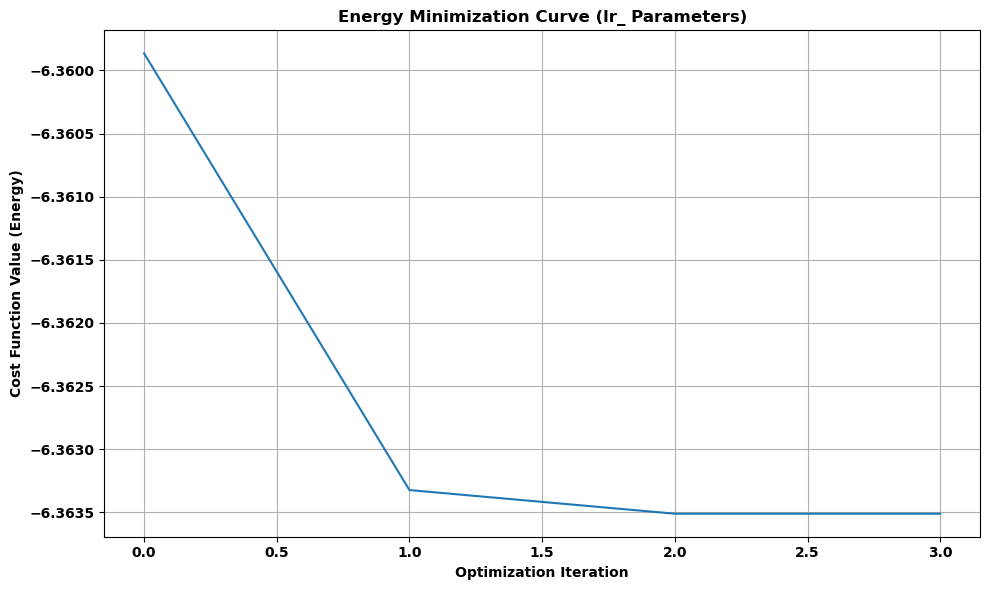

In [24]:
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector

estimator = StatevectorEstimator()

# --- 1. Create Static Parameter Dictionaries ---
static_params_lr, variable_params_lr = create_parameter_dictionaries_from_circuit(cc_grn_circuit_mo)

# Update static_params_lr with values from all_params and all_params2
for param in static_params_lr:
    if param.name in [p.name for p in all_params_ct1_mo]:
        # Access value directly by name
        static_params_lr[param] = all_params_ct1_mo[next(p for p in all_params_ct1_mo if p.name == param.name)]
    elif param.name in [p.name for p in all_params_ct2_mo]:
        # Access value directly by name
        static_params_lr[param] = all_params_ct2_mo[next(p for p in all_params_ct2_mo if p.name == param.name)]

x0_lr = np.zeros(len(variable_params_lr))  # Initial lr_ values

# Create the combined parameter dictionary.
all_params_lr_mo = static_params_lr.copy()
all_params_lr_mo.update(dict(zip(variable_params_lr, x0_lr)))

print(all_params_lr_mo)

interaction_observable_lr_mo = create_interaction_observable_general(interactions_lr, ng_ct1 + ng_ct2)
print("Interaction observable LR custom: ", interaction_observable_lr_mo)

cost_values = []
result_lr_bfgs = minimize(
    cost_func_wrapper, 
    x0_lr,
    args=(all_params_lr_mo, cc_grn_circuit_mo, interaction_observable_lr_mo, estimator, variable_params_lr),  # Correct args
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params_lr_mo, cc_grn_circuit_mo, interaction_observable_lr_mo, estimator, variable_params_lr))  # Correct callback
)

print(result_lr_bfgs)

# --- 6. Results and DataFrame ---
optimized_lr_values = result_lr_bfgs.x

# Update the lr_ parameters in the combined dictionary (optional)
all_params_lr_mo.update(dict(zip(variable_params_lr, optimized_lr_values)))

# --- 7. Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve (lr_ Parameters)")
plt.grid(True)
plt.tight_layout()
plt.show()

The counts are: {'011111': 164, '111111': 55, '000010': 114, '010100': 47, '110101': 6, '001101': 17, '001111': 65, '011001': 8, '010010': 199, '011011': 5, '111101': 5, '000100': 23, '000000': 19, '011101': 29, '010000': 28, '110010': 103, '000011': 6, '110000': 18, '111110': 15, '111100': 6, '010011': 16, '110011': 15, '010110': 2, '001011': 4, '011100': 7, '110100': 24, '111001': 3, '010101': 4, '001001': 3, '000101': 2, '001100': 3, '111010': 2, '110001': 1, '000001': 1, '111000': 2, '111011': 2, '000110': 1}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:135: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


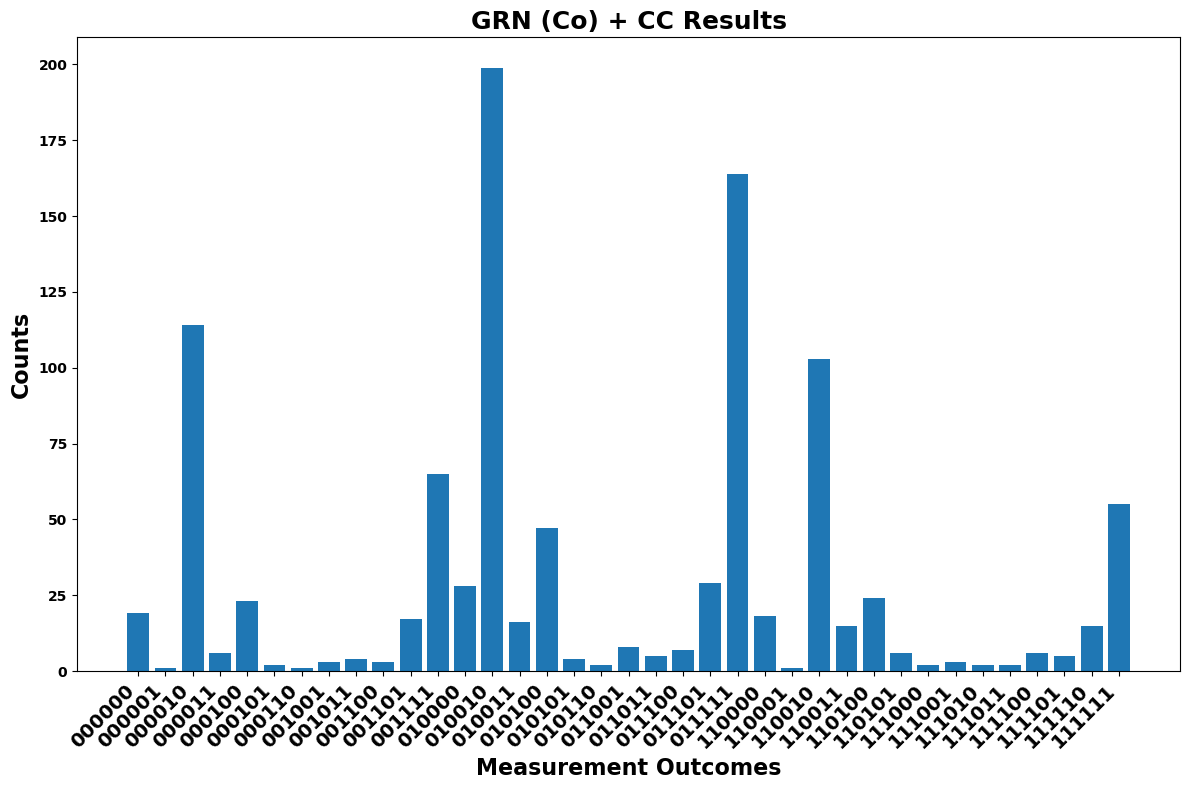

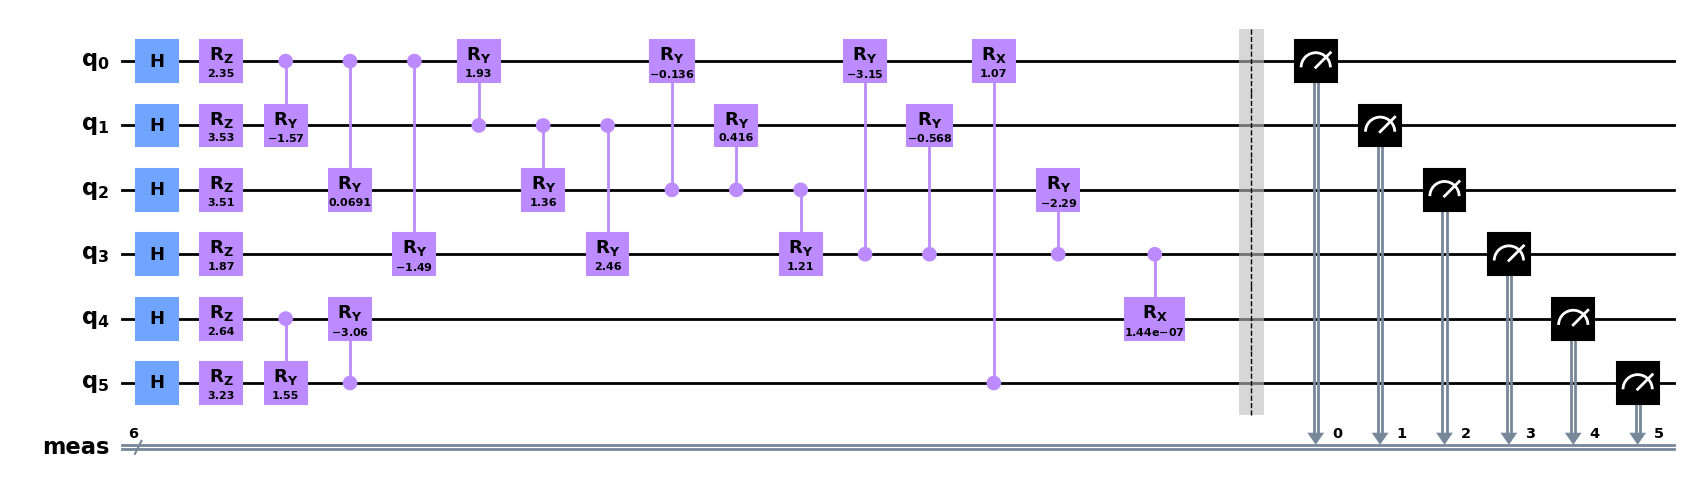

In [25]:
counts_cc_grn_co, bound_circuit_cc_grn_co = evaluate_and_plot_ansatz(cc_grn_circuit_co, all_params_lr_co, shots=1024, title="GRN (Co) + CC Results")
bound_circuit_cc_grn_co.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

The counts are: {'110010': 179, '000010': 127, '110100': 43, '010010': 213, '111010': 2, '000100': 41, '000000': 15, '000011': 40, '001111': 15, '110110': 4, '001011': 4, '010011': 61, '010111': 2, '010100': 61, '011011': 12, '000110': 2, '111101': 4, '010000': 29, '111011': 4, '011111': 34, '111100': 19, '010110': 3, '001010': 1, '011101': 26, '111110': 11, '011001': 2, '001100': 4, '011110': 3, '110000': 11, '010101': 9, '110011': 4, '110111': 1, '011100': 4, '000001': 1, '111111': 15, '110101': 2, '001110': 1, '001101': 5, '110001': 3, '010001': 3, '000101': 2, '001001': 1, '000111': 1}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:135: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


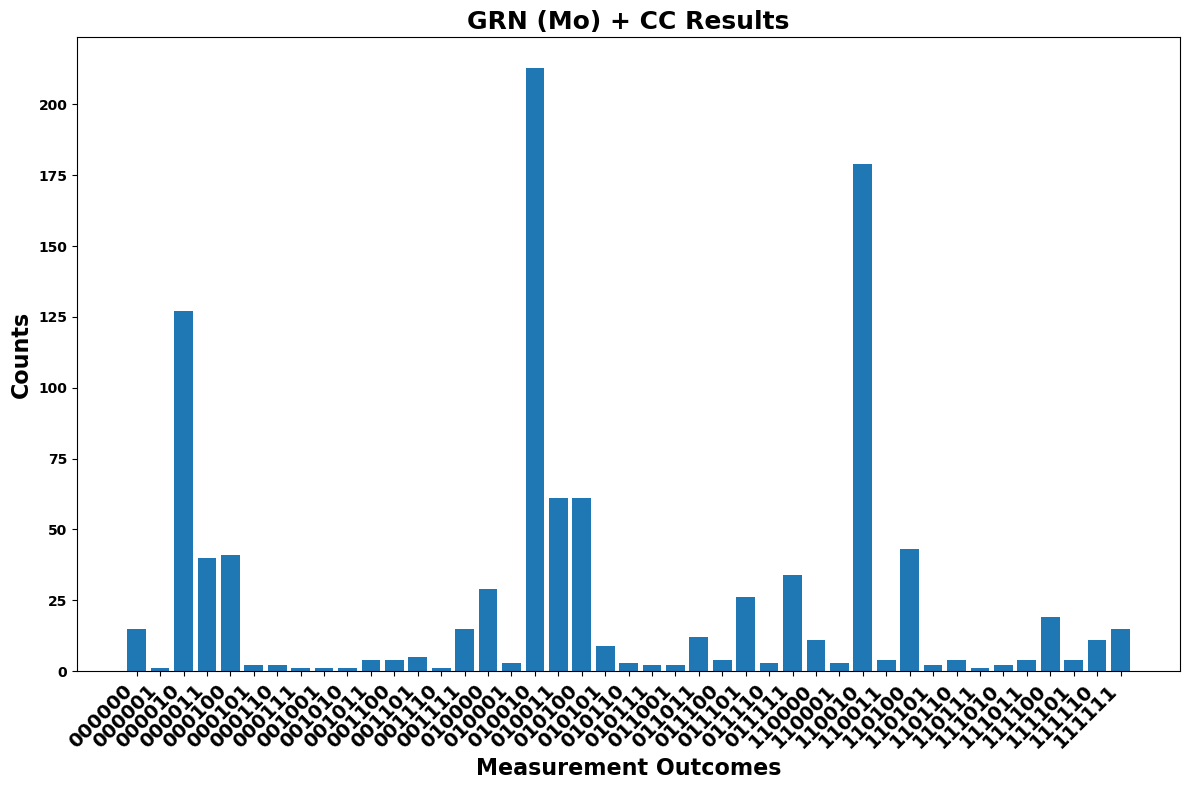

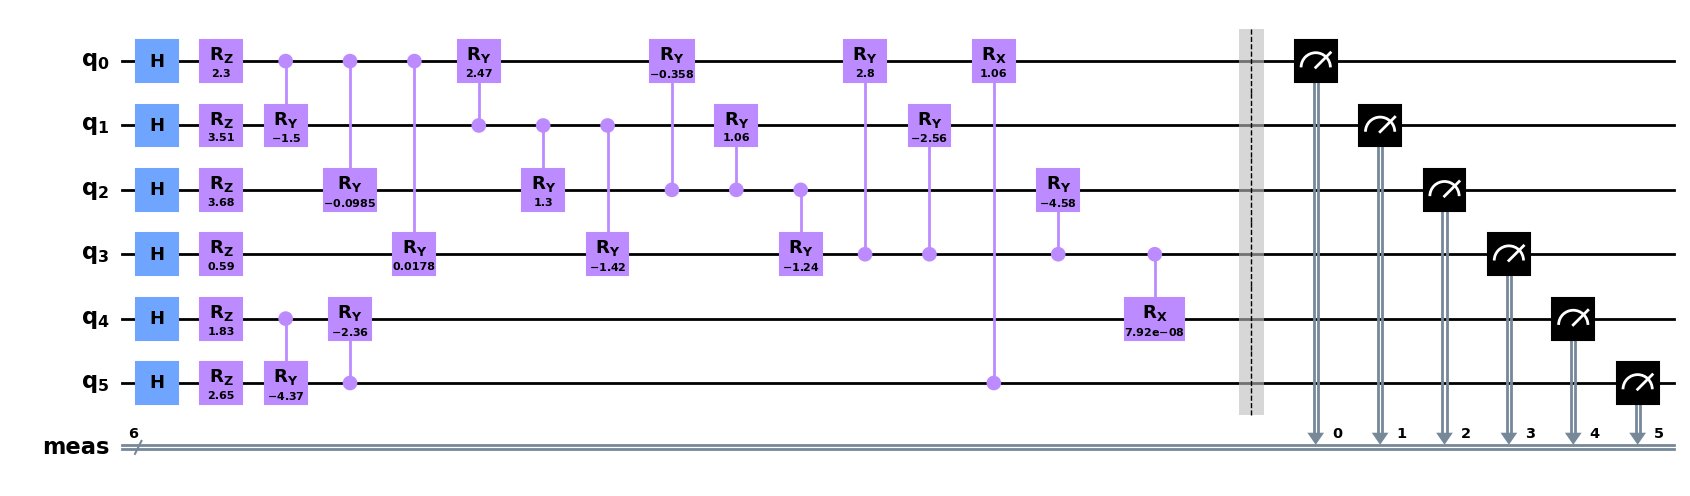

In [26]:
counts_cc_grn_mo, bound_circuit_cc_grn_mo = evaluate_and_plot_ansatz(cc_grn_circuit_mo, all_params_lr_mo, shots=1024, title="GRN (Mo) + CC Results")
bound_circuit_cc_grn_mo.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

In [27]:
def filter_bitstrings_from_interactions(interactions_lr, num_qubits):
    """
    Generates bit string patterns based on the given interactions_lr
    for plotting specific bitstring patterns.
    Args:
        interactions_lr (dict): A dictionary representing interactions,
                                 where keys are tuples of qubit indices
                                 and values are interaction strengths.
        num_qubits (int): The total number of qubits in the system.

    Returns:
        list: A list of bit string patterns with '1' at the interacting
              qubit positions and '0' elsewhere.
    """
    patterns = []
    for interaction in interactions_lr:
        pattern = ['.'] * num_qubits
        for qubit_index in interaction:
            if 0 <= qubit_index < num_qubits:
                pattern[num_qubits - 1 - qubit_index] = '1'  # Adjust for bit order
        patterns.append("".join(pattern))
    return patterns

bitstring_patterns = filter_bitstrings_from_interactions(interactions_lr, cc_grn_circuit_co.num_qubits)
print(bitstring_patterns)

['1....1', '.11...']


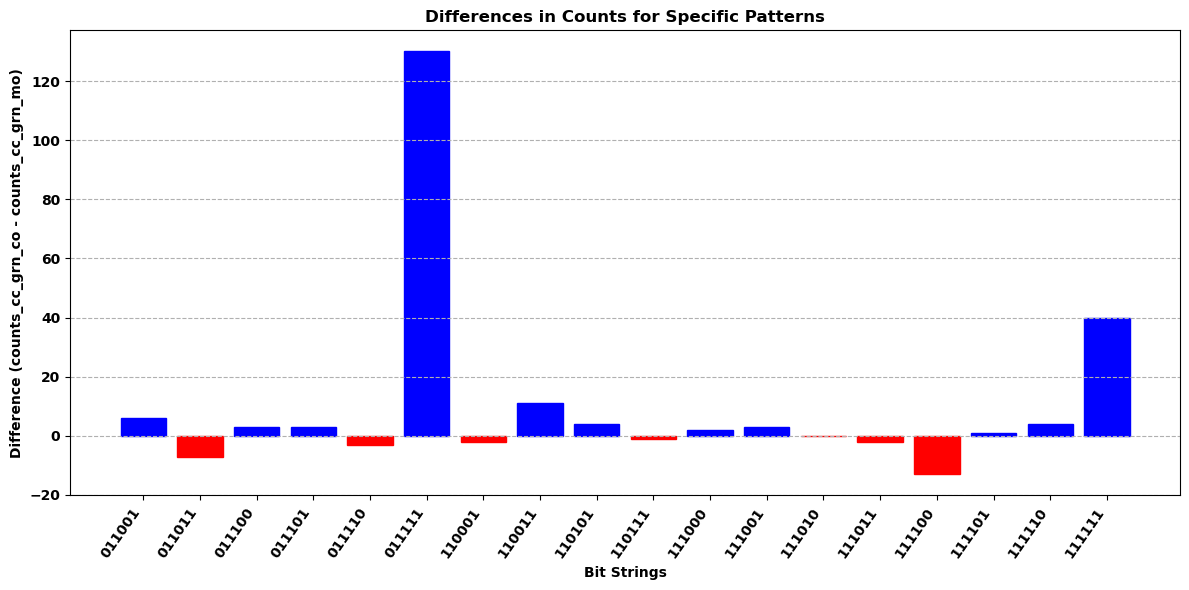

In [28]:
import matplotlib.pyplot as plt
import numpy as np

differences = {}

# Calculate the differences, handling cases where bitstrings are not common
all_bitstrings = set(counts_cc_grn_co.keys()) | set(counts_cc_grn_mo.keys())

for key in all_bitstrings:
    count_co = counts_cc_grn_co.get(key, 0)
    count_mo = counts_cc_grn_mo.get(key, 0)
    differences[key] = count_co - count_mo


def matches_pattern(bitstring, pattern):
    if len(bitstring) != len(pattern):
        return False
    for i in range(len(bitstring)):
        if pattern[i] != '.' and pattern[i] != bitstring[i]:
            return False
    return True

# Filter bitstrings based on the defined patterns
filtered_bitstrings = []
filtered_differences = []

for bitstring, difference in differences.items():
    for pattern in bitstring_patterns:
        if matches_pattern(bitstring, pattern):
            filtered_bitstrings.append(bitstring)
            filtered_differences.append(difference)
            break # Move to the next bitstring once a match is found

# Sort the filtered bitstrings for better visualization
sorted_indices = np.argsort(filtered_bitstrings)
filtered_bitstrings = [filtered_bitstrings[i] for i in sorted_indices]
filtered_differences = [filtered_differences[i] for i in sorted_indices]

# Create the bar plot with filtered data
plt.figure(figsize=(12, 6))
bars = plt.bar(filtered_bitstrings, filtered_differences, edgecolor='black')

# Color the bars based on the sign of the difference
for bar, diff in zip(bars, filtered_differences):
    if diff > 0:
        bar.set_color('blue')  # Or another color for positive differences
    else:
        bar.set_color('red')   # Or another color for negative differences


plt.xlabel('Bit Strings')
plt.ylabel('Difference (counts_cc_grn_co - counts_cc_grn_mo)')
plt.title(f'Differences in Counts for Specific Patterns')
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--')
plt.show()

In [29]:
print(gl_recv[::-1], gl_source[::-1])

['TGFB1', 'PDGFRB'] ['PDGFB', 'HIF1A', 'SMAD3', 'TGFBR2']


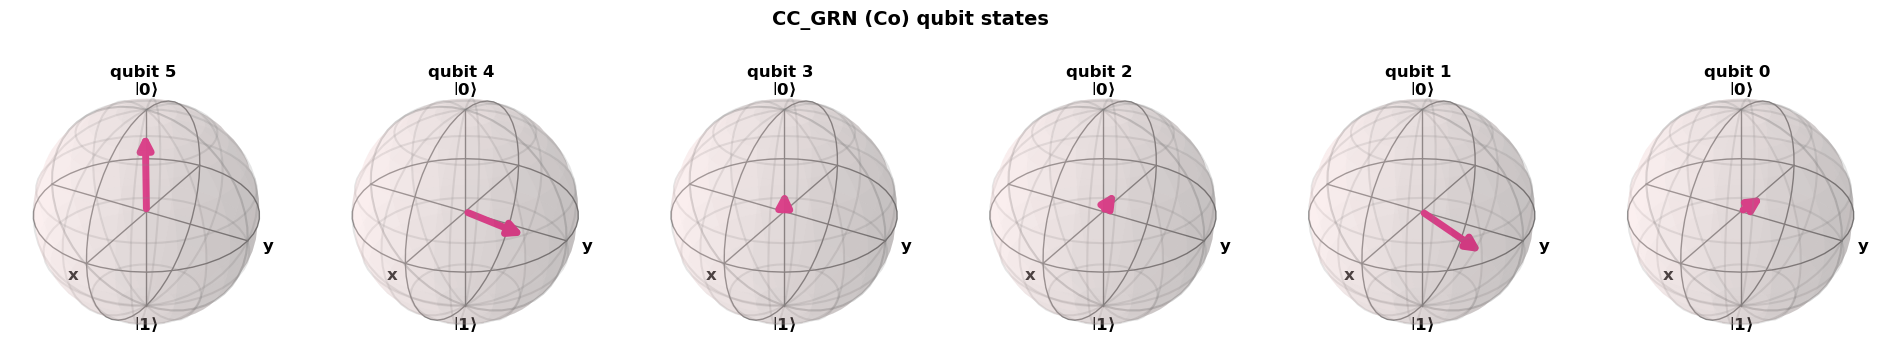

In [110]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.exceptions import QiskitError 
from qiskit.quantum_info import DensityMatrix, Statevector
from qiskit.visualization import plot_bloch_multivector, plot_state_qsphere, plot_state_city, plot_state_hinton

bound_qc = cc_grn_circuit_co.copy()
bound_qc.assign_parameters(all_params_lr_co, inplace=True)
state = Statevector(bound_qc)
plot_bloch_multivector(state, title='CC_GRN (Co) qubit states', font_size=12, title_font_size=14, figsize=(4,4),  reverse_bits=True)
#plot_state_qsphere(state)

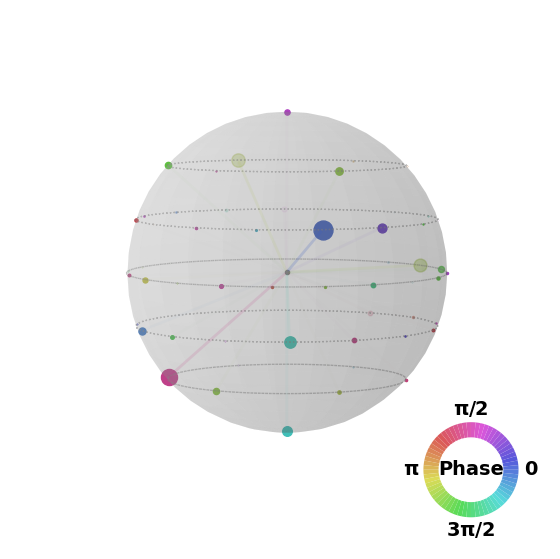

In [111]:
plot_state_qsphere(state, show_state_labels=False)

In [112]:
import numpy as np
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace

# Convert to DensityMatrix
density_matrix = DensityMatrix(bound_qc)

n_qubits = density_matrix.num_qubits

for qubit_to_keep in range(n_qubits):
    # Create a list of qubits to trace out (all except the current one)
    trace_out_qubits = list(range(n_qubits))
    trace_out_qubits.pop(qubit_to_keep)

    # Perform partial trace using the standalone function
    reduced_density_matrix_data = partial_trace(density_matrix, trace_out_qubits).data

    print(f"Reduced Density Matrix for Qubit {qubit_to_keep}:")
    print(reduced_density_matrix_data)

    # The reduced density matrix is 2x2. The diagonal elements are the probabilities
    prob_0 = np.real(reduced_density_matrix_data[0, 0])
    prob_1 = np.real(reduced_density_matrix_data[1, 1])
    print(f"  Probability of |0>: {prob_0:.4f}")
    print(f"  Probability of |1>: {prob_1:.4f}")

Reduced Density Matrix for Qubit 0:
[[ 0.60575752-3.65993540e-17j -0.01827437-1.13970951e-01j]
 [-0.01827437+1.13970951e-01j  0.39424248+1.60009810e-17j]]
  Probability of |0>: 0.6058
  Probability of |1>: 0.3942
Reduced Density Matrix for Qubit 1:
[[ 0.25313387-2.43772906e-17j -0.17786689-2.21806288e-01j]
 [-0.17786689+2.21806288e-01j  0.74686613+3.77891766e-18j]]
  Probability of |0>: 0.2531
  Probability of |1>: 0.7469
Reduced Density Matrix for Qubit 2:
[[ 0.534967  -8.98070622e-18j -0.14961998+1.20595929e-02j]
 [-0.14961998-1.20595929e-02j  0.465033  -1.16176667e-17j]]
  Probability of |0>: 0.5350
  Probability of |1>: 0.4650
Reduced Density Matrix for Qubit 3:
[[ 0.59580411-4.08196295e-17j -0.03696573+1.77986719e-02j]
 [-0.03696573-1.77986719e-02j  0.40419589+2.02212565e-17j]]
  Probability of |0>: 0.5958
  Probability of |1>: 0.4042
Reduced Density Matrix for Qubit 4:
[[ 0.25050372-2.99231749e-18j -0.31638836-1.45803643e-01j]
 [-0.31638836+1.45803643e-01j  0.74949628-1.76060554e

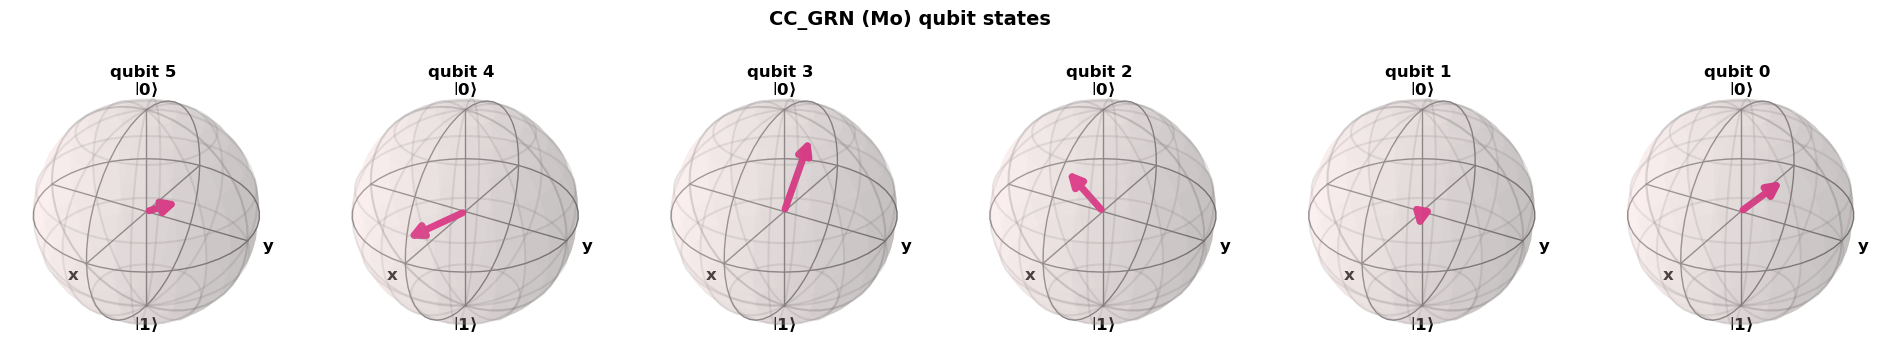

In [113]:
bound_qc = cc_grn_circuit_mo.copy()
bound_qc.assign_parameters(all_params_lr_mo, inplace=True)
state = Statevector(bound_qc)
plot_bloch_multivector(state, title='CC_GRN (Mo) qubit states', font_size=12, title_font_size=14, figsize=(4,4),  reverse_bits=True)

#plot_state_qsphere(state)

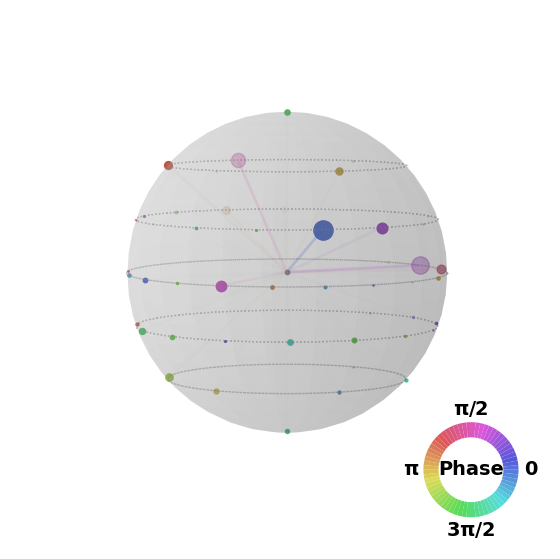

In [114]:
plot_state_qsphere(state , show_state_labels=False)

In [115]:
import numpy as np
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace

# Convert to DensityMatrix
density_matrix = DensityMatrix(bound_qc)

n_qubits = density_matrix.num_qubits

for qubit_to_keep in range(n_qubits):
    # Create a list of qubits to trace out (all except the current one)
    trace_out_qubits = list(range(n_qubits))
    trace_out_qubits.pop(qubit_to_keep)

    # Perform partial trace using the standalone function
    reduced_density_matrix_data = partial_trace(density_matrix, trace_out_qubits).data

    print(f"Reduced Density Matrix for Qubit {qubit_to_keep}:")
    print(reduced_density_matrix_data)

    # The reduced density matrix is 2x2. The diagonal elements are the probabilities
    prob_0 = np.real(reduced_density_matrix_data[0, 0])
    prob_1 = np.real(reduced_density_matrix_data[1, 1])
    print(f"  Probability of |0>: {prob_0:.4f}")
    print(f"  Probability of |1>: {prob_1:.4f}")

Reduced Density Matrix for Qubit 0:
[[0.76367283-7.85120132e-19j 0.06628376-2.53000370e-01j]
 [0.06628376+2.53000370e-01j 0.23632717+1.14319140e-17j]]
  Probability of |0>: 0.7637
  Probability of |1>: 0.2363
Reduced Density Matrix for Qubit 1:
[[ 0.28332875-1.46718944e-17j -0.15559247+1.09784564e-01j]
 [-0.15559247-1.09784564e-01j  0.71667125+2.53186883e-17j]]
  Probability of |0>: 0.2833
  Probability of |1>: 0.7167
Reduced Density Matrix for Qubit 2:
[[0.69475827+2.54959299e-17j 0.05161516+1.61768156e-01j]
 [0.05161516-1.61768156e-01j 0.30524173-1.48491361e-17j]]
  Probability of |0>: 0.6948
  Probability of |1>: 0.3052
Reduced Density Matrix for Qubit 3:
[[ 0.83831773-2.31716451e-18j -0.12127479-6.48081117e-02j]
 [-0.12127479+6.48081117e-02j  0.16168227+1.29639584e-17j]]
  Probability of |0>: 0.8383
  Probability of |1>: 0.1617
Reduced Density Matrix for Qubit 4:
[[ 0.25023867-4.31519641e-18j -0.00924511+3.29707608e-01j]
 [-0.00924511-3.29707608e-01j  0.74976133+1.49619903e-17j]]
 